In [ ]:
%%writefile gen_zipf.py
import os, sys
import numpy as np
import pandas as pd
import random

if __name__ == "__main__":
    if len(sys.argv) != 6:
        print("Usage: %s <save_path> <num_resources> <num_samples> <zipf_param> <num_progs>" % sys.argv[0])
        exit(0)

    save_path = sys.argv[1]
    num_files = int(sys.argv[2])
    num_samples = int(sys.argv[3])
    param = float(sys.argv[4])
    num_progs = int(sys.argv[5])

    df = None
    for i in range(num_progs):
        files = np.arange(num_files)
        ranks = np.random.permutation(files) + 1
        pdf = 1 / np.power(ranks, param)
        pdf /= np.sum(pdf)
        requests = np.random.choice(files, size=num_samples, p=pdf)
        operations = np.full_like(requests, 0)
        executions = np.full_like(requests, 1)

        tmp = pd.DataFrame({'blocksector': requests, 'read/write': operations, 'boot/exec': executions})
        if df is None:
            df = tmp
        else:
            df = pd.concat((df, tmp), axis=0)
    df.to_csv(save_path, index=False, header=True)

Writing gen_zipf.py


In [ ]:
!mkdir -p data
!python gen_zipf.py data/zipf_10k.csv 1000 10000 1.2 1

In [ ]:
import sys, os, random
import numpy as np
import pandas as pd

class DataLoader(object):
    def __init__(self):
        self.requests = []
        self.operations = []

    def get_requests(self):
        pass
    def get_operations(self):
        pass

class DataLoaderPintos(DataLoader):
    def __init__(self, progs, boot=False):
        super(DataLoaderPintos, self).__init__()

        if isinstance(progs, str): progs = [progs]
        for prog in progs:
            df = pd.read_csv(prog, header=0)
            if not boot: df = df.loc[df['boot/exec'] == 1, :]
            self.requests += list(df['blocksector'])
            self.operations += list(df['read/write'])

    def get_requests(self):
        return self.requests

    def get_operations(self):
        return self.operations

class DataLoaderZipf(DataLoader):
    def __init__(self, num_files, num_samples, param, num_progs=1, operation='random'):
        super(DataLoaderZipf, self).__init__()

        for i in range(num_progs):
            files = np.arange(num_files)
            # Random ranks. Note that it starts from 1.
            ranks = np.random.permutation(files) + 1
            # Distribution
            pdf = 1 / np.power(ranks, param)
            pdf /= np.sum(pdf)
            # Draw samples
            self.requests += np.random.choice(files, size=num_samples, p=pdf).tolist()
            if operation == 'random':
                self.operations += np.random.choice([0, 1], size=num_samples).tolist()
            else:
                self.operations += np.full(num_samples, int(operation)).tolist()

    def get_requests(self):
        return self.requests

    def get_operations(self):
        return self.operations

In [ ]:
class Cache(object):
    def __init__(self, requests, cache_size,
        terms=[10, 100, 1000], # Time span for different terms
        feature_selection=('Base',), # Features. Available 'Base', 'UT', and 'CT'

        # Reward functions. Here are the default params
        # 1. Zhong et. al. - (name='zhong', short_reward=1.0, long_span=100, beta=0.5)
        # 2. Ours - (name='our', alpha=0.5, psi=10, mu=1, beta=0.3), let psi=0 to remove penalty
        reward_params=dict(name='our', alpha=0.5, psi=10, mu=1, beta=0.3),

        # leave none for random read/writes
        operations=None,
        allow_skip=False,
        normalize=False # normalize all state features between 0 and 1
    ):
        # If the cache allows skip eviction
        # Network caching, disk caching do allow skipping eviction and grab resource directly.
        # However, cache between CPU and memory requires every accessed data to be cached beforehand.
        self.allow_skip = allow_skip

        # Counters
        self.total_count = 0
        self.miss_count = 0
        self.evict_count = 0

        self.normalize = normalize

        # Load requests
        if isinstance(requests, DataLoader):   # From data loader
            self.requests = requests.get_requests()
            self.operations = requests.get_operations()
        else:                                   # From array
            self.requests = requests
            self.operations = operations
            # random read/writes
            if self.operations is None:
                self.operations = [random.randint(0, 1) for i in range(len(self.requests))]
        self.cur_index = -1

        if len(self.requests) <= cache_size:
            raise ValueError("The count of requests are too small. Try larger one.")

        if len(self.requests) != len(self.operations):
            raise ValueError("Not every request is assigned with an operation.")

        # Important: Reward function
        self.reward_params = reward_params

        # Elasped terms - short, middle and long
        self.FEAT_TREMS = terms

        # Cache
        self.cache_size = cache_size
        self.slots = [-1] * self.cache_size
        self.used_times = [-1] * self.cache_size
        self.cached_times = [-1] * self.cache_size
        self.access_bits = [False] * self.cache_size
        self.dirty_bits = [False] * self.cache_size
        self.resource_freq = {}

        # Action & feature information
        self.sel_features = feature_selection
        self.n_actions = self.cache_size + 1 if allow_skip else self.cache_size
        self.n_features = 0
        if 'Base' in self.sel_features:
            self.n_features += (self.cache_size + 1) * len(self.FEAT_TREMS)
        if 'UT' in self.sel_features:
            self.n_features += self.cache_size
        if 'CT' in self.sel_features:
            self.n_features += self.cache_size
        # ... we've removed CS feature

    # Display the current cache state
    def display(self):
        print(self.slots)

    # Return miss rate
    def miss_rate(self):
        return self.miss_count / self.total_count

    def reset(self):
        self.total_count = 0
        self.miss_count = 0

        self.cur_index = 0

        self.slots = [-1] * self.cache_size
        self.used_times = [-1] * self.cache_size
        self.access_bits = [False] * self.cache_size
        self.dirty_bits = [False] * self.cache_size

        slot_id = 0
        while slot_id < self.cache_size and self.cur_index < len(self.requests):
            request = self._current_request()
            if request not in self.slots:
                self.miss_count += 1
                self.slots[slot_id] = request
                self.cached_times[slot_id] = self.cur_index
                self._hit_cache(slot_id)
                slot_id += 1
            self.total_count += 1
            self.cur_index += 1

        # Back to the last requested index
        self.cur_index -= 1

        # Run to the first miss as the inital decision epoch.
        self._run_until_miss()

        return self._get_observation()

    # Has program finished?
    def hasDone(self):
        return self.cur_index == len(self.requests)

    # Make action at the current decision epoch and run to the
    # next decision epoch.
    def step(self, action):
        if self.hasDone():
            raise ValueError("Simulation has finished, use reset() to restart simulation.")

        if not self.allow_skip:
            action += 1

        if action < 0 or action > len(self.slots):
            raise ValueError("Invalid action %d taken." % action)

        # Evict slot of (aciton - 1). action == 0 means skipping eviction.
        if action != 0:
            out_resource = self.slots[action - 1]
            in_resource = self._current_request()
            slot_id = action - 1
            self.slots[slot_id] = in_resource
            self.cached_times[slot_id] = self.cur_index
            self._hit_cache(slot_id)
            self.evict_count += 1
        else:
            skip_resource = self._current_request()

        last_index = self.cur_index

        # Proceed kernel and resource accesses until next miss.
        self._run_until_miss()

        # Get observation.
        observation = self._get_observation()

        # Zhong et. al. 2018
        if self.reward_params['name'].lower() == "zhong":
            # Compute reward: R = short term + long term
            reward = 0.0

            # Total count of hit since last decision epoch
            hit_count = self.cur_index - last_index - 1
            if hit_count != 0: reward += self.reward_params['short_reward']
            # Long term
            start = last_index
            end = last_index + self.reward_params['long_span']
            if end > len(self.requests): end = len(self.requests)
            long_term_hit = 0
            next_reqs = self.requests[start : end]
            for rc in self.slots:
                long_term_hit += next_reqs.count(rc)
            reward += self.reward_params['beta'] * long_term_hit / (end - start)

        # Ours
        elif self.reward_params['name'].lower() == "our":
            # Ours (Βελτιωμένο για Νευρωνικά Δίκτυα)

            import math
            reward = 0.0

            # 1. Κανονικοποιημένο Hit Reward (Αποτρέπει την έκρηξη του Loss)
            hit_count = self.cur_index - last_index - 1
            # Χρησιμοποιούμε λογάριθμο: Αν hit_count = 1000, το reward θα είναι περίπου 6.9
            reward += math.log(hit_count + 1)

            miss_resource = self._current_request()

            if action != 0:
                # 2. Σωστή Τιμωρία (Penalty) για κακή αντικατάσταση
                # Η σωστή λογική στην Cache: "Πέταξα κάτι που θα μου χρειαζόταν πολύ σύντομα;"
                # Ας κοιτάξουμε τα επόμενα 50 requests (στο μέλλον)
                future_horizon = 50
                start = self.cur_index + 1
                end = min(start + future_horizon, len(self.requests))
                future_requests = self.requests[start : end]

                # Αν το αρχείο που πετάξαμε (out_resource) ζητηθεί στο άμεσο μέλλον, ΤΙΜΩΡΙΑ!
                if out_resource in future_requests:
                    # Όσο πιο νωρίς το χρειαστούμε, τόσο μεγαλύτερη η τιμωρία
                    idx_next_use = future_requests.index(out_resource)
                    # Τιμωρία από -psi έως -0 (κανονικοποιημένη)
                    reward -= self.reward_params['psi'] * (1.0 - (idx_next_use / future_horizon))
            else:
                # Skipping eviction penalty (αν επιτρέπεται)
                if miss_resource == skip_resource:
                    reward -= self.reward_params['psi']

        return observation, reward

    # Run until next cache miss
    def _run_until_miss(self):
        self.cur_index += 1
        while self.cur_index < len(self.requests):
            request = self._current_request()
            if request not in self.resource_freq:
                self.resource_freq[request] = 0
            self.resource_freq[request] += 1
            self.total_count += 1

            if request not in self.slots:
                self.miss_count += 1
                break
            else:
                slot_id = self.slots.index(request)
                self._hit_cache(slot_id)
            self.cur_index += 1
        return self.hasDone()

    # In case that the simulation has ended, but we still need the current
    # request for the last observation and reward. Return -1 to eliminate
    # any defects.
    def _current_request(self):
        return -1 if self.hasDone() else self.requests[self.cur_index]

    # Simulate cache hit, update attributes.
    def _hit_cache(self, slot_id):
        # Set access bit
        self.access_bits[slot_id] = True
        # If the operation is write
        if self.operations[self.cur_index] == 1:
            # Set dirty bit
            self.dirty_bits[slot_id] = True
        # Record last used time
        self.used_times[slot_id] = self.cur_index

    # The number of requests on rc_id among last `term` requests.
    def _elapsed_requests(self, term, rc_id):
        start = self.cur_index - term + 1
        if start < 0: start = 0
        end = self.cur_index + 1
        if end > len(self.requests): end = len(self.requests)
        # print(f"XYZ term={term} rcid={rc_id} {self.requests[start : end].count(rc_id)}")
        if self.normalize:
            return (1.00 * self.requests[start : end].count(rc_id))/term
        else:
            return (1.00 * self.requests[start : end].count(rc_id))

    # The number of requests on rc_id among next `term` requests.
    def _next_requests(self, term, rc_id):
        start = self.cur_index + 1
        if start < 0: start = 0
        end = self.cur_index + term
        if end > len(self.requests): end = len(self.requests)
        return self.requests[start : end].count(rc_id)

    # Return the observation features for reinforcement agent
    def _get_features(self):
        # [Freq, F1, F2, ..., Fc] where Fi = [Rs, Rm, Rl]
        # i.e. the request times in short/middle/long term for each
        # cached resource and the currently requested resource.

        # base
        features = np.concatenate([
            np.array([self._elapsed_requests(t, self._current_request()) for t in self.FEAT_TREMS])
            , np.array([self._elapsed_requests(t, rc) for rc in self.slots for t in self.FEAT_TREMS])
        ], axis=0)

        # last accessed time
        if 'UT' in self.sel_features:
            if self.normalize:
                features = np.concatenate([
                    features
                    , np.array([self.used_times[i]/np.max(self.used_times) for i in range(self.cache_size)])
                ], axis=0)
            else:
                features = np.concatenate([
                    features
                    , np.array([self.used_times[i] for i in range(self.cache_size)])
                ], axis=0)

        # cached time
        if 'CT' in self.sel_features:
            if self.normalize:
                features = np.concatenate([
                    features,
                    np.array([self.cached_times[i]/np.max(self.cached_times) for i in range(self.cache_size)])
                ], axis=0)
            else:
                features = np.concatenate([
                    features,
                    np.array([self.cached_times[i] for i in range(self.cache_size)])
                ], axis=0)


        return features

    def _get_observation(self):
        return dict(features=self._get_features(),
            cache_state=self.slots.copy(),
            cached_times=self.cached_times.copy(),
            last_used_times=self.used_times.copy(),
            total_use_frequency=[self.resource_freq.get(r, 0) for r in self.slots],
            access_bits=self.access_bits.copy(),
            dirty_bits=self.dirty_bits.copy()
        )

#NEW PPO

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ShallowActor(nn.Module):
    def __init__(self, n_features, n_actions):
        super(ShallowActor, self).__init__()
        self.fc1 = nn.Linear(n_features, 128)
        self.fc2 = nn.Linear(128, n_actions)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.softmax(self.fc2(x))
        return x


class ShallowCritic(nn.Module):
    def __init__(self, n_features):
        super(ShallowCritic, self).__init__()
        self.fc1 = nn.Linear(n_features, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class DeepActor(nn.Module):
    def __init__(self, n_features, n_actions):
        super(DeepActor, self).__init__()
        self.fc1 = nn.Linear(n_features, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, n_actions)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.softmax(self.fc4(x))
        return x


class DeepCritic(nn.Module):
    def __init__(self, n_features):
        super(DeepCritic, self).__init__()
        self.fc1 = nn.Linear(n_features, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x



class _FeatureReshaper:
    """
    Helper που ξέρει πώς να σπάσει το flat features vector σε per-block tokens.

    Δομή του flat vector (από Cache._get_features):
      [req_short, req_mid, req_long,                   ← current request (n_terms)
       b0_short,  b0_mid,  b0_long,                    ┐
       b1_short,  b1_mid,  b1_long,                    │ cache_size * n_terms
       ...                                             ┘
       ut_0, ut_1, ..., ut_{N-1},                      ← αν has_ut  (cache_size)
       ct_0, ct_1, ..., ct_{N-1}]                      ← αν has_ct  (cache_size)
    """
    def __init__(self, cache_size: int, n_terms: int, has_ut: bool, has_ct: bool):
        self.cache_size = cache_size
        self.n_terms    = n_terms
        self.has_ut     = has_ut
        self.has_ct     = has_ct

        # Feature sizes per token
        self.req_feat_size   = n_terms
        self.block_feat_size = n_terms + int(has_ut) + int(has_ct)

    def __call__(self, x: torch.Tensor):
        """
        x: (batch, n_features)
        Returns:
            req_feats   : (batch, n_terms)
            block_tokens: (batch, cache_size, block_feat_size)
        """
        B = x.shape[0]
        ptr = 0

        # Current-request frequencies
        req_feats = x[:, ptr : ptr + self.n_terms]
        ptr += self.n_terms

        # Per-block frequencies
        block_freqs = x[:, ptr : ptr + self.cache_size * self.n_terms]
        block_freqs = block_freqs.view(B, self.cache_size, self.n_terms)
        ptr += self.cache_size * self.n_terms

        extras = []
        if self.has_ut:
            ut = x[:, ptr : ptr + self.cache_size].unsqueeze(-1)  # (B, N, 1)
            extras.append(ut)
            ptr += self.cache_size
        if self.has_ct:
            ct = x[:, ptr : ptr + self.cache_size].unsqueeze(-1)
            extras.append(ct)

        if extras:
            block_tokens = torch.cat([block_freqs] + extras, dim=-1)
        else:
            block_tokens = block_freqs

        return req_feats, block_tokens


class TransformerActor(nn.Module):
    """
    Κάθε cache block + current request γίνεται ένα token.
    Ο Transformer κάνει attention μεταξύ τους και βγάζει
    πιθανότητα eviction για κάθε block.

    Sequence: [CUR_REQUEST | BLOCK_0 | BLOCK_1 | ... | BLOCK_{N-1}]
    Output   : softmax πάνω στα N block tokens → action probs
    """
    def __init__(
        self,
        cache_size : int,
        n_actions  : int,
        n_terms    : int  = 3,
        has_ut     : bool = False,
        has_ct     : bool = False,
        d_model    : int  = 64,
        nhead      : int  = 4,
        n_layers   : int  = 2,
        dropout    : float = 0.1,
    ):
        super().__init__()
        self.reshaper = _FeatureReshaper(cache_size, n_terms, has_ut, has_ct)
        self.n_actions = n_actions

        # Separate linear projections: request token vs block tokens
        # (διαφορετικά features sizes)
        self.req_proj   = nn.Linear(self.reshaper.req_feat_size,   d_model)
        self.block_proj = nn.Linear(self.reshaper.block_feat_size, d_model)

        # Learnable positional embeddings  (seq_len = cache_size + 1)
        self.pos_embed = nn.Embedding(cache_size + 1, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Per-block score head → eviction logit
        self.score_head = nn.Linear(d_model, 1)
        self.softmax    = nn.Softmax(dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        req_feats, block_tokens = self.reshaper(x)

        # Project to d_model
        req_emb   = self.req_proj(req_feats).unsqueeze(1)          # (B, 1, d)
        block_emb = self.block_proj(block_tokens)                  # (B, N, d)

        # Concat: current request is the first token
        seq = torch.cat([req_emb, block_emb], dim=1)               # (B, N+1, d)

        # Add positional embeddings
        positions = torch.arange(seq.size(1), device=x.device)
        seq = seq + self.pos_embed(positions)

        # Transformer
        out = self.transformer(seq)                                 # (B, N+1, d)

        # Eviction scores — only over block tokens (skip index 0 = request token)
        block_out = out[:, 1:, :]                                   # (B, N, d)
        logits    = self.score_head(block_out).squeeze(-1)          # (B, N)

        # If allow_skip, n_actions = cache_size + 1:
        # prepend a "skip" logit derived from the request token
        if self.n_actions > block_out.shape[1]:
            skip_logit = self.score_head(out[:, 0:1, :]).squeeze(-1)  # (B, 1)
            logits = torch.cat([skip_logit, logits], dim=1)            # (B, N+1)

        return self.softmax(logits)


class TransformerCritic(nn.Module):
    """
    Shared encoder with Actor (for weight sharing)
    or independent encoders for each block.
    """
    def __init__(
        self,
        cache_size : int,
        n_terms    : int  = 3,
        has_ut     : bool = False,
        has_ct     : bool = False,
        d_model    : int  = 64,
        nhead      : int  = 4,
        n_layers   : int  = 2,
        dropout    : float = 0.1,
    ):
        super().__init__()
        self.reshaper = _FeatureReshaper(cache_size, n_terms, has_ut, has_ct)

        self.req_proj   = nn.Linear(self.reshaper.req_feat_size,   d_model)
        self.block_proj = nn.Linear(self.reshaper.block_feat_size, d_model)
        self.pos_embed  = nn.Embedding(cache_size + 1, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.value_head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        req_feats, block_tokens = self.reshaper(x)

        req_emb   = self.req_proj(req_feats).unsqueeze(1)
        block_emb = self.block_proj(block_tokens)
        seq       = torch.cat([req_emb, block_emb], dim=1)

        positions = torch.arange(seq.size(1), device=x.device)
        seq = seq + self.pos_embed(positions)

        out = self.transformer(seq)           # (B, N+1, d)

        # Mean pool across all tokens for global state value
        pooled = out.mean(dim=1)              # (B, d)
        return self.value_head(pooled)        # (B, 1)

import torch.nn.functional as F

class CNNActor(nn.Module):
    def __init__(self, cache_size: int, n_actions: int, n_terms: int = 3, has_ut: bool = False, has_ct: bool = False):
        super().__init__()
        self.reshaper = _FeatureReshaper(cache_size, n_terms, has_ut, has_ct)
        self.n_actions = n_actions


        in_channels = self.reshaper.block_feat_size

        # 1D Convolutions με kernel_size=1
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=32, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=16, kernel_size=1)

        self.conv3 = nn.Conv1d(in_channels=16, out_channels=1, kernel_size=1)

        self.softmax = nn.Softmax(dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        req_feats, block_tokens = self.reshaper(x)

        # (Batch, Channels, Length)
        x_cnn = block_tokens.permute(0, 2, 1)

        x_cnn = F.relu(self.conv1(x_cnn))
        x_cnn = F.relu(self.conv2(x_cnn))
        logits = self.conv3(x_cnn) # (Batch, 1, N_blocks)

        logits = logits.squeeze(1) # (Batch, N_blocks)


        if self.n_actions > logits.shape[1]:
            skip_logit = torch.zeros((logits.shape[0], 1), device=logits.device)
            logits = torch.cat([skip_logit, logits], dim=1)

        return self.softmax(logits)


class CNNCritic(nn.Module):
    def __init__(self, cache_size: int, n_terms: int = 3, has_ut: bool = False, has_ct: bool = False):
        super().__init__()
        self.reshaper = _FeatureReshaper(cache_size, n_terms, has_ut, has_ct)

        in_channels = self.reshaper.block_feat_size

        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=32, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=32, kernel_size=1)

        self.fc1 = nn.Linear(32 + self.reshaper.req_feat_size, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        req_feats, block_tokens = self.reshaper(x)

        x_cnn = block_tokens.permute(0, 2, 1)

        x_cnn = F.relu(self.conv1(x_cnn))
        x_cnn = F.relu(self.conv2(x_cnn))

        # Global Average Pooling blocks
        pooled = x_cnn.mean(dim=2) # (Batch, 32)


        state_repr = torch.cat([pooled, req_feats], dim=1)

        v = F.relu(self.fc1(state_repr))
        value = self.fc2(v)

        return value


def normalize_features(features):
    return (features - np.mean(features)) / (np.std(features) + 1e-8)


def _infer_transformer_params(n_features: int, cache_size: int, n_terms: int):

    base = (cache_size + 1) * n_terms
    remainder = n_features - base
    has_ut = remainder >= cache_size
    has_ct = remainder >= 2 * cache_size
    return has_ut, has_ct




class PPOAgent(LearnerAgent):
    def __init__(
        self,
        n_actions,
        n_features,
        architecture        = 'deep',   # 'shallow' | 'deep' | 'transformer'
        actor_learning_rate = 0.001,
        critic_learning_rate= 0.01,
        gamma               = 0.99,
        clip_param          = 0.2,
        ppo_epochs          = 10,
        batch_size          = 32,
        verbose             = 0,

        cache_size          = None,
        n_terms             = 3,
        transformer_d_model = 64,
        transformer_nhead   = 4,
        transformer_n_layers= 2,
        transformer_dropout = 0.1,
    ):
        self.n_actions    = n_actions
        self.n_features   = n_features
        self.gamma        = gamma
        self.clip_param   = clip_param
        self.ppo_epochs   = ppo_epochs
        self.batch_size   = batch_size
        self.verbose      = verbose
        self.learn_step_counter = 0
        self.memory       = []

        self.actor_loss_his  = []
        self.critic_loss_his = []


        if architecture == 'shallow':
            self.actor  = ShallowActor(n_features, n_actions).to(device)
            self.critic = ShallowCritic(n_features).to(device)

        elif architecture == 'deep':
            self.actor  = DeepActor(n_features, n_actions).to(device)
            self.critic = DeepCritic(n_features).to(device)

        elif architecture == 'transformer':
            if cache_size is None:
                raise ValueError("architecture='transformer' needs cache_size.")
            has_ut, has_ct = _infer_transformer_params(n_features, cache_size, n_terms)

            self.actor = TransformerActor(
                cache_size  = cache_size, n_actions = n_actions,
                n_terms     = n_terms, has_ut = has_ut, has_ct = has_ct,
                d_model     = transformer_d_model, nhead = transformer_nhead,
                n_layers    = transformer_n_layers, dropout = transformer_dropout
            ).to(device)

            self.critic = TransformerCritic(
                cache_size  = cache_size, n_terms = n_terms,
                has_ut = has_ut, has_ct = has_ct,
                d_model = transformer_d_model, nhead = transformer_nhead,
                n_layers = transformer_n_layers, dropout = transformer_dropout
            ).to(device)

        elif architecture == 'cnn':
            if cache_size is None:
                raise ValueError("cache_size is required for CNN.")
            has_ut, has_ct = _infer_transformer_params(n_features, cache_size, n_terms)

            self.actor = CNNActor(
                cache_size=cache_size, n_actions=n_actions,
                n_terms=n_terms, has_ut=has_ut, has_ct=has_ct
            ).to(device)

            self.critic = CNNCritic(
                cache_size=cache_size, n_terms=n_terms,
                has_ut=has_ut, has_ct=has_ct
            ).to(device)

            self.actor = TransformerActor(
                cache_size  = cache_size,
                n_actions   = n_actions,
                n_terms     = n_terms,
                has_ut      = has_ut,
                has_ct      = has_ct,
                d_model     = transformer_d_model,
                nhead       = transformer_nhead,
                n_layers    = transformer_n_layers,
                dropout     = transformer_dropout,
            ).to(device)

            self.critic = TransformerCritic(
                cache_size  = cache_size,
                n_terms     = n_terms,
                has_ut      = has_ut,
                has_ct      = has_ct,
                d_model     = transformer_d_model,
                nhead       = transformer_nhead,
                n_layers    = transformer_n_layers,
                dropout     = transformer_dropout,
            ).to(device)

        else:
            raise ValueError(f"Invalid architecture: '{architecture}'. "
                             )

        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=actor_learning_rate)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_learning_rate)
        self.loss_func = nn.MSELoss()



    def store_transition(self, s, a, r, s_, old_log_prob):
        s_features      = normalize_features(np.array(s['features']))
        s_next_features = normalize_features(np.array(s_['features']))
        self.memory.append((s_features, a, r, s_next_features, old_log_prob))

    def choose_action(self, observation, return_log_prob=True):
        features = normalize_features(np.array(observation['features']))
        features_tensor = torch.tensor(features, dtype=torch.float).unsqueeze(0).to(device)
        probabilities = self.actor(features_tensor)
        dist = torch.distributions.Categorical(probabilities)
        if np.random.uniform() < 0.2:
            action = LRUAgent._choose_action(observation)
            log_prob = dist.log_prob(torch.tensor(action).to(device))
        else:
            action   = dist.sample()
            log_prob = dist.log_prob(action)
            action   = action.item()
        return (action, log_prob.item()) if return_log_prob else action.item()

    def learn(self):
        if len(self.memory) < self.batch_size:
            return

        sample_indices = random.sample(range(len(self.memory)), self.batch_size)
        sample = [self.memory[i] for i in sample_indices]

        states, actions, rewards, next_states, old_log_probs = zip(*sample)
        self.memory = []

        states        = torch.tensor(np.vstack(states),        dtype=torch.float).to(device)
        actions       = torch.tensor(np.array(actions),        dtype=torch.long).to(device)
        rewards       = torch.tensor(np.array(rewards),        dtype=torch.float).to(device)
        next_states   = torch.tensor(np.vstack(next_states),   dtype=torch.float).to(device)
        old_log_probs = torch.tensor(np.array(old_log_probs),  dtype=torch.float).to(device)

        for epoch in range(self.ppo_epochs):
            state_values  = self.critic(states).squeeze()
            new_probs     = self.actor(states)
            dist          = torch.distributions.Categorical(new_probs)
            new_log_probs = dist.log_prob(actions)

            ratios     = torch.exp(new_log_probs - old_log_probs)
            advantages = (
                rewards
                + self.gamma * self.critic(next_states).detach().squeeze()
                - state_values
            ).detach()
            surr1      = ratios * advantages
            surr2      = torch.clamp(ratios, 1 - self.clip_param, 1 + self.clip_param) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            # Gradient clipping
            nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=0.5)
            self.actor_optimizer.step()

            if epoch == self.ppo_epochs - 1:
                critic_loss = self.loss_func(
                    state_values,
                    rewards + self.gamma * self.critic(next_states).detach().squeeze()
                )
                self.critic_optimizer.zero_grad()
                critic_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=0.5)
                self.critic_optimizer.step()

                self.actor_loss_his.append(actor_loss.item())
                self.critic_loss_his.append(critic_loss.item())

            if self.verbose:
                print(f'PPO Step: {self.learn_step_counter}, '
                      f'Actor Loss: {actor_loss.item():.4f}, '
                      f'Critic Loss: {critic_loss.item():.4f}')

        self.learn_step_counter += 1

    def save(self, filepath):
        checkpoint = {
            'actor_state_dict':  self.actor.state_dict(),
            'critic_state_dict': self.critic.state_dict(),
            'actor_optimizer':   self.actor_optimizer.state_dict(),
            'critic_optimizer':  self.critic_optimizer.state_dict(),
            'actor_loss_his':    self.actor_loss_his,
            'critic_loss_his':   self.critic_loss_his,
            'learn_step_counter':self.learn_step_counter,
        }
        torch.save(checkpoint, filepath)

    def load(self, filepath):
        checkpoint = torch.load(filepath, map_location=device)
        self.actor.load_state_dict(checkpoint['actor_state_dict'])
        self.critic.load_state_dict(checkpoint['critic_state_dict'])
        self.actor_optimizer.load_state_dict(checkpoint['actor_optimizer'])
        self.critic_optimizer.load_state_dict(checkpoint['critic_optimizer'])
        self.actor_loss_his     = checkpoint['actor_loss_his']
        self.critic_loss_his    = checkpoint['critic_loss_his']
        self.learn_step_counter = checkpoint['learn_step_counter']

    def plot_cost(self, save_path=None, window=10):
        import matplotlib.pyplot as plt
        import numpy as np

        if not self.actor_loss_his or not self.critic_loss_his:
            return

        # moving average
        def moving_average(data, window_size):
            if len(data) < window_size:
                return data
            weights = np.ones(window_size) / window_size
            return np.convolve(data, weights, mode='valid')


        actor_smooth = moving_average(self.actor_loss_his, window)
        critic_smooth = moving_average(self.critic_loss_his, window)


        if len(self.actor_loss_his) < window:
            x_actor = np.arange(len(self.actor_loss_his))
        else:
            x_actor = np.arange(window - 1, len(self.actor_loss_his))

        if len(self.critic_loss_his) < window:
            x_critic = np.arange(len(self.critic_loss_his))
        else:
            x_critic = np.arange(window - 1, len(self.critic_loss_his))


        plt.figure(figsize=(12, 5))

        # actor loss
        plt.subplot(1, 2, 1)
        plt.plot(self.actor_loss_his, label='Raw Actor Loss', color='blue', alpha=0.3)
        if len(actor_smooth) > 0:
            plt.plot(x_actor, actor_smooth, label=f'Smooth (Window={window})', color='darkblue', linewidth=2)
        plt.title('Actor Loss over time')
        plt.xlabel('Learn Steps')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        # critic loss
        plt.subplot(1, 2, 2)
        plt.plot(self.critic_loss_his, label='Raw Critic Loss', color='red', alpha=0.3)
        if len(critic_smooth) > 0:
            plt.plot(x_critic, critic_smooth, label=f'Smooth (Window={window})', color='darkred', linewidth=2)
        plt.title('Critic Loss over time')
        plt.xlabel('Learn Steps')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path)
        else:
            plt.show()
        plt.close()



In [ ]:
import sys

# Abstract class
class CacheAgent(object):
    def __init__(self, n_actions): pass
    def choose_action(self, observation): pass
    def store_transition(self, s, a, r, s_): pass

class ReflexAgent(CacheAgent):
    def __init__(self, n_actions): pass

    @staticmethod
    def _choose_action(n_actions): pass

class LearnerAgent(CacheAgent):
    def __init__(self, n_actions): pass
    def learn(self): pass

In [ ]:
import random
import numpy as np


class RandomAgent(ReflexAgent):
    def __init__(self, n_actions):
        self.n_actions = n_actions

    @staticmethod
    def _choose_action(n_actions):
        return random.randint(0, n_actions - 1)

    def choose_action(self, observation):
        return RandomAgent._choose_action(self.n_actions)

class LRUAgent(ReflexAgent):
    def __init__(self, n_actions):
        self.n_actions = n_actions

    @staticmethod
    def _choose_action(observation):
        used_times = np.array(observation['last_used_times'])
        min_idx = np.argmin(used_times)
        return min_idx

    def choose_action(self, observation):
        min_idx = LRUAgent._choose_action(observation)
        if min_idx < 0 or min_idx > self.n_actions:
            raise ValueError("LRUAgent: Error index %d" % min_idx)
        return min_idx

class MRUAgent(ReflexAgent):
    def __init__(self, n_actions):
        self.n_actions = n_actions

    @staticmethod
    def _choose_action(observation):
        used_times = np.array(observation['last_used_times'])
        max_idx = np.argmax(used_times)
        return max_idx

    def choose_action(self, observation):
        max_idx = MRUAgent._choose_action(observation)
        if max_idx < 0 or max_idx > self.n_actions:
            raise ValueError("MRUAgent: Error index %d" % max_idx)
        return max_idx

class LFUAgent(ReflexAgent):
    def __init__(self, n_actions):
        self.n_actions = n_actions

    @staticmethod
    def _choose_action(observation):
        freq = observation['total_use_frequency']
        min_idx = np.argmin(freq)
        return min_idx

    def choose_action(self, observation):
        min_idx = LFUAgent._choose_action(observation)
        if min_idx < 0 or min_idx > self.n_actions:
            raise ValueError("LFUAgent: Error index %d" % max_idx)
        return min_idx

#main

In [ ]:
import argparse
import time

def main():
    parser = argparse.ArgumentParser(description='Train RL approaches for cache replacement problem')
    parser.add_argument('-c', '--cachesize', default=50, type=int, choices=[5, 10, 50, 100])
    parser.add_argument('-e', '--early', default=-1, type=int)
    parser.add_argument('-f', '--feature', default='all', type=str, choices=['all', 'Base'])
    parser.add_argument('-d', '--data', default="zipf_10k.csv", type=str, choices=["zipf.csv", "zipf_10k.csv"])
    parser.add_argument('-n', '--network', default='attention', choices=['deep', 'shallow', 'attention','transformer','cnn'], type=str)
    parser.add_argument('-a', '--agent', default='DQN', choices=['SarsaLambda', 'DQN', 'ActorCritic', 'ActorCriticQ', 'PPO', 'REINFORCE', 'LRU', 'LFU', 'MRU', 'Random'], type=str)

    # common args for all NN models
    parser.add_argument('--lr', default=1e-3, type=float)

    # arguments for SARSA LAMBDA
    parser.add_argument('--num_tilings', default=10, type=int)
    parser.add_argument('--lam', default=0.8, type=float)
    parser.add_argument('--tile_width', default=1.0, type=float)

    # args for PPO
    parser.add_argument('--ppo_epochs', default=10, type=int)


    args = parser.parse_args(args=[
    '--agent', 'PPO',
    '-d', 'zipf_10k.csv',
    '-c', '50',
    '--network', 'transformer',
    '--lr', '0.0003',
    '--ppo_epochs', '20'
])

    print(args)

    if args.feature == 'all':
        features = ('Base', 'UT', 'CT')
    elif args.feature == 'Base':
        features = ('Base')
    else:
        raise NotImplementedError()

    dataloader = DataLoaderPintos([f"data/{args.data}"])
    env = Cache(dataloader, args.cachesize,
        feature_selection=features,
        reward_params = dict(name='our', alpha=0.5, psi=3, mu=1, beta=0.3),
        allow_skip=False, normalize=True
    )

    if args.agent == 'SarsaLambda':
        agent = SarsaLambdaAgent(
            env.n_actions, env.n_features,
            num_tilings = args.num_tilings,
            tile_width = args.tile_width,
            lam = args.lam
        )
    elif args.agent == 'REINFORCE':
        agent = REINFORCEAgent(env.n_actions, env.n_features, nn_type = args.network, learning_rate = args.lr)
    elif args.agent == 'ActorCritic':
        agent = ActorCriticAgent(env.n_actions, env.n_features,
            actor_learning_rate=0.0001,
            critic_learning_rate=0.01,
            reward_decay=0.99,
            batch_size=16,
            architecture='deep'
        )
    elif args.agent == 'ActorCriticQ':
        agent = ActorCriticQAgent(env.n_actions, env.n_features,
            actor_learning_rate=args.lr,
            critic_learning_rate=args.lr,
            reward_decay=0.95,
            batch_size=32,
            architecture=args.network
        )
    elif args.agent == 'PPO':
        agent = PPOAgent(
            n_actions=env.n_actions,
            n_features=env.n_features,
            architecture=args.network,
            cache_size=args.cachesize,
            actor_learning_rate=args.lr,
            critic_learning_rate=args.lr,
            ppo_epochs=args.ppo_epochs,
            transformer_d_model=128,
            transformer_nhead=4,
            transformer_n_layers=2
        )
    elif args.agent == 'Random':
        agent = RandomAgent(env.n_actions)
    elif args.agent == 'LRU':
        agent = LRUAgent(env.n_actions)
    elif args.agent == 'LFU':
        agent = LFUAgent(env.n_actions)
    elif args.agent == 'MRU':
        agent = MRUAgent(env.n_actions)
    elif args.agent == 'DQN':
        agent = DQNAgent(env.n_actions, env.n_features,
            learning_rate=args.lr,
            reward_decay=0.99,
            e_greedy_min=(0.0, 0.05),
            e_greedy_max=(0.2, 0.8),
            e_greedy_init=(0.1, 0.5),
            e_greedy_increment=(0.005, 0.01),
            e_greedy_decrement=(0.001, 0.0005),
            history_size=50,
            dynamic_e_greedy_iter=25,
            reward_threshold=3,
            explore_mentor = 'LRU',
            replace_target_iter=100,
            memory_size=50000,
            batch_size=128,
            output_graph=False,
            verbose=0
        )

    step = 0
    episodes = 30 if isinstance(agent, LearnerAgent) else 1

    import os
    import csv
    from datetime import datetime

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"results/{args.agent}_cache{args.cachesize}_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)

    csv_filename = os.path.join(save_dir, "training_logs.csv")
    csv_file = open(csv_filename, mode='w', newline='')
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(['Episode', 'Total_Steps', 'Miss_Rate', 'Total_Reward'])


    start_time_step = time.time()
    start_time_episode = time.time()


    for episode in range(episodes):
        observation = env.reset()
        episode_reward = 0

        while True:
            if args.agent=='PPO':
                action, old_log_prob = agent.choose_action(observation)
            else:
                action = agent.choose_action(observation)

            observation_, reward = env.step(action)
            episode_reward += reward

            if env.hasDone():
                break

            if args.agent=='PPO':
                agent.store_transition(observation, action, reward, observation_, old_log_prob)
            else:
                agent.store_transition(observation, action, reward, observation_)

            #if isinstance(agent, LearnerAgent) and (step > 20) and (step % 5 == 0):
                #agent.learn()

            observation = observation_


            if step % 1000 == 0:
                mr = env.miss_rate()
                print(f"### Time={time.time() - start_time_step:.2f} Agent={args.agent}, CacheSize={args.cachesize} Episode={episode}, Step={step}: Accesses={env.total_count}, Misses={env.miss_count}, MissRate={mr:.4f}")
                start_time_step = time.time()

            if args.early > 0 and env.total_count > args.early:
                mr = env.miss_rate()
                print(f"### Time={time.time() - start_time_step:.2f} Agent={args.agent}, CacheSize={args.cachesize} Episode={episode}, Step={step}: Accesses={env.total_count}, Misses={env.miss_count}, MissRate={mr:.4f}")
                exit()

            step += 1
        if args.agent == 'PPO':
          agent.learn()


        mr = env.miss_rate()
        print(f"=== Time={time.time() - start_time_episode:.2f} Agent={args.agent}, CacheSize={args.cachesize} Episode={episode}: Accesses={env.total_count}, Misses={env.miss_count}, MissRate={mr:.4f}, TotalReward={episode_reward:.2f} ===")
        start_time_episode = time.time()

        csv_writer.writerow([episode, env.total_count, mr, episode_reward])
        csv_file.flush()

        if episode % 10 == 0 or episode == episodes - 1:
            model_path = os.path.join(save_dir, f"model_ep{episode}.pth")
            if hasattr(agent, 'save'):
                agent.save(model_path)


                plot_path = os.path.join(save_dir, f"loss_plot_ep{episode}.png")
                agent.plot_cost(save_path=plot_path)


    csv_file.close()

if __name__ == "__main__":
    main()

Namespace(cachesize=50, early=-1, feature='all', data='zipf_10k.csv', network='transformer', agent='PPO', lr=0.0003, num_tilings=10, lam=0.8, tile_width=1.0, ppo_epochs=20)
### Time=0.01 Agent=PPO, CacheSize=50 Episode=0, Step=0: Accesses=121, Misses=52, MissRate=0.4298
### Time=4.99 Agent=PPO, CacheSize=50 Episode=0, Step=1000: Accesses=2687, Misses=1052, MissRate=0.3915
### Time=5.96 Agent=PPO, CacheSize=50 Episode=0, Step=2000: Accesses=5287, Misses=2052, MissRate=0.3881
### Time=5.20 Agent=PPO, CacheSize=50 Episode=0, Step=3000: Accesses=8112, Misses=3052, MissRate=0.3762
=== Time=20.33 Agent=PPO, CacheSize=50 Episode=0: Accesses=10000, Misses=3718, MissRate=0.3718, TotalReward=1454.93 ===
### Time=6.45 Agent=PPO, CacheSize=50 Episode=1, Step=4000: Accesses=992, Misses=385, MissRate=0.3881
### Time=5.16 Agent=PPO, CacheSize=50 Episode=1, Step=5000: Accesses=3750, Misses=1385, MissRate=0.3693
### Time=5.98 Agent=PPO, CacheSize=50 Episode=1, Step=6000: Accesses=6600, Misses=2385, Mis

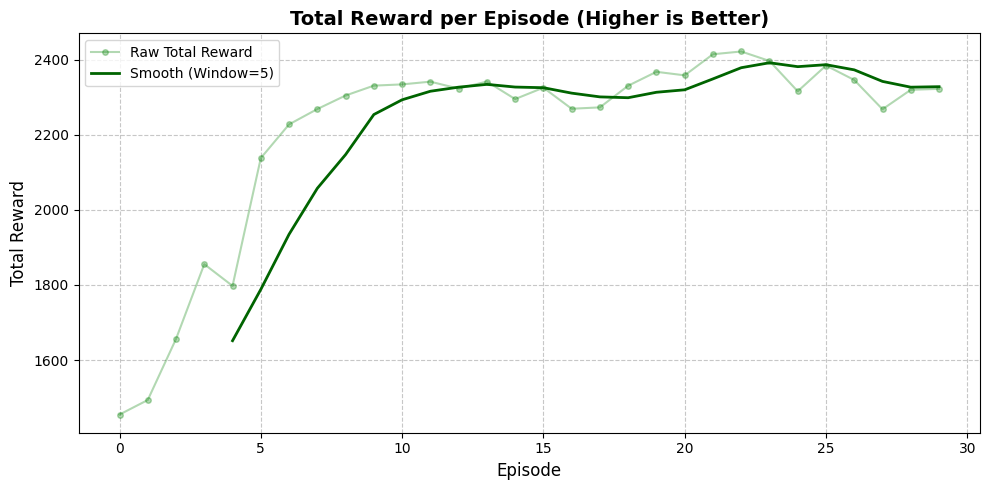

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


csv_path = "results/xoxo1/training_logs.csv"

if not os.path.exists(csv_path):
    print(f"NOT FOUND!")
else:

    df = pd.read_csv(csv_path)

    episodes = df['Episode'].values
    rewards = df['Total_Reward'].values

    #  Moving Average (Smoothing)
    def moving_average(data, window_size):
        if len(data) < window_size:
            return data
        weights = np.ones(window_size) / window_size
        return np.convolve(data, weights, mode='valid')


    window = 5
    smooth_rewards = moving_average(rewards, window)


    if len(rewards) < window:
        x_smooth = episodes
    else:
        x_smooth = episodes[window - 1:]


    plt.figure(figsize=(10, 5))


    plt.plot(episodes, rewards, label='Raw Total Reward', color='green', alpha=0.3, marker='o', markersize=4)


    if len(smooth_rewards) > 0:
        plt.plot(x_smooth, smooth_rewards, label=f'Smooth (Window={window})', color='darkgreen', linewidth=2)

    plt.title('Total Reward per Episode (Higher is Better)', fontsize=14, fontweight='bold')
    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Total Reward', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()